# 05 · Transformer Encoder from Scratch

**DeepCodeGuard** · Week 5

RNNs read code one token at a time. A **Transformer** lets every token look at every other token **directly, in one step**, through *self-attention*. That's why it should handle long-range dependencies like "pointer allocated on line 3, freed on line 40, used on line 41".

We build every piece **ourselves** from basic PyTorch layers (no `nn.Transformer`), so each syllabus concept is visible in code:

| Component | What it does |
|---|---|
| **Token embedding** | Learned vector per token |
| **Positional encoding** | Self-attention has no notion of order, so we add sine/cosine position signals |
| **Multi-head self-attention** | Each head computes $\text{softmax}(QK^\top/\sqrt{d_k})\,V$ and looks for different relationships |
| **Feed-forward network** | Per-token two-layer MLP |
| **Residual + LayerNorm** | Keeps gradients healthy in deep stacks |
| **[CLS] token** | A special token at position 0, whose final vector represents the whole function |

**Experiments**
- *Experiment 4*: Transformer vs RNN. Can self-attention capture code dependencies better than recurrence?
- *Ablation*: Transformer **with vs without positional encoding**. Does token order matter at all?

> ⚙️ Runtime → Change runtime type → **T4 GPU**. 2 variants × 3 seeds ≈ 20–40 minutes. Wait for section 9 before saving to GitHub.

## 0 · Setup

In [2]:
!git clone -q https://github.com/reenupalle/deepcodeguard.git 2>/dev/null || (cd deepcodeguard && git pull -q)
%cd /content/deepcodeguard
!pip install -q datasets
!python src/deepcodeguard/data/download.py

/content/deepcodeguard
README.md: 100% 5.60k/5.60k [00:00<00:00, 16.0MB/s]

data/train-00000-of-00001.parquet: downloading bytes:  36% 6.35M/17.8M [00:01<00:02, 5.24MB/s, 75.0kB/s  ]
data/train-00000-of-00001.parquet: downloading bytes: 100% 17.7M/17.7M [00:01<00:00, 10.3MB/s, 1.69MB/s  ]
data/train-00000-of-00001.parquet: reconstructing file: 100% 17.8M/17.8M [00:01<00:00, 10.4MB/s, 1.70MB/s  ]

data/validation-00000-of-00001.parquet: downloading bytes:  29% 638k/2.21M [00:01<00:03, 477kB/s]
data/validation-00000-of-00001.parquet: downloading bytes: 100% 2.20M/2.20M [00:01<00:00, 1.58MB/s,  211kB/s  ]
data/validation-00000-of-00001.parquet: reconstructing file: 100% 2.21M/2.21M [00:01<00:00, 1.59MB/s,  213kB/s  ]

data/test-00000-of-00001.parquet: downloading bytes:  20% 436k/2.23M [00:01<00:05, 357kB/s]
data/test-00000-of-00001.parquet: downloading bytes: 100% 2.21M/2.21M [00:01<00:00, 1.76MB/s,  214kB/s  ]
data/test-00000-of-00001.parquet: reconstructing file: 100% 2.23M/2.23M [00:0

## 1 · Configuration
A deliberately **small** Transformer (2 layers, 4 heads, 128 dimensions), about the same size as our BiLSTM, so the comparison is about architecture, not model size.

In [3]:
import math
import re
import sys
import time
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

sys.path.insert(0, "src")
from deepcodeguard.evaluation.metrics import val_then_test

CONFIG = {
    "max_len": 512, "min_freq": 3, "max_vocab": 30_000,
    "d_model": 128, "n_heads": 4, "n_layers": 2, "d_ff": 256, "dropout": 0.1,
    "batch_size": 64, "lr": 3e-4, "weight_decay": 0.01, "warmup_ratio": 0.1,
    "max_epochs": 15, "patience": 3, "grad_clip": 1.0,
}
SEEDS = [42, 43, 44]
VARIANTS = {"Transformer": True, "Transformer (no positional enc.)": False}   # name: use positional encoding
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cuda


## 2 · Data and vocabulary
Same tokeniser and vocabulary rules as notebooks 03–04. One difference: every sequence starts with a **`[CLS]`** token (ID 2), as in the spec: `[CLS] static int foo ( ... ) { ... }`.

In [4]:
data = {s: pd.read_json(f"data/raw/{s}.jsonl", lines=True) for s in ["train", "validation", "test"]}
y = {s: d["target"].astype(int).values for s, d in data.items()}

TOKEN_RE = re.compile(r"[A-Za-z_]\w*|\d+|\S")
PAD, UNK, CLS = 0, 1, 2
tokens = {s: [TOKEN_RE.findall(code) for code in d["func"]] for s, d in data.items()}
counts = Counter(t for toks in tokens["train"] for t in toks)
vocab = ["<pad>", "<unk>", "[CLS]"] + [t for t, c in counts.most_common(CONFIG["max_vocab"]) if c >= CONFIG["min_freq"]]
stoi = {t: i for i, t in enumerate(vocab)}
SEQ_LEN = CONFIG["max_len"] + 1   # +1 for [CLS]


def encode(toks):
    ids = [CLS] + [stoi.get(t, UNK) for t in toks[:CONFIG["max_len"]]]
    return ids + [PAD] * (SEQ_LEN - len(ids))


datasets = {s: TensorDataset(torch.tensor([encode(t) for t in tokens[s]]),
                             torch.tensor(y[s], dtype=torch.float32)) for s in data}
print(f"Vocabulary size: {len(vocab):,}   sequence length: {SEQ_LEN}")
print("Example:", ["[CLS]"] + tokens["train"][0][:10])

Vocabulary size: 30,003   sequence length: 513
Example: ['[CLS]', 'static', 'av_cold', 'int', 'vdadec_init', '(', 'AVCodecContext', '*', 'avctx', ')', '{']


## 3 · Positional encoding
$PE_{(pos, 2i)} = \sin(pos / 10000^{2i/d})$ and $PE_{(pos, 2i+1)} = \cos(pos / 10000^{2i/d})$

Each position gets a unique pattern of waves at different frequencies, which is added to the token embedding. The plot shows the first 64 dimensions for the first 100 positions.

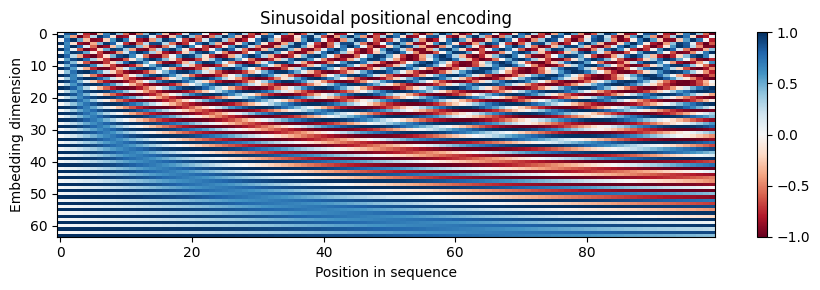

In [5]:
import matplotlib.pyplot as plt


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len):
        super().__init__()
        pos = torch.arange(max_len).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe)

    def forward(self, x):
        return x + self.pe[: x.size(1)]


pe = PositionalEncoding(CONFIG["d_model"], SEQ_LEN).pe
fig, ax = plt.subplots(figsize=(9, 3))
im = ax.imshow(pe[:100, :64].T, aspect="auto", cmap="RdBu")
ax.set_xlabel("Position in sequence")
ax.set_ylabel("Embedding dimension")
ax.set_title("Sinusoidal positional encoding")
fig.colorbar(im, ax=ax)
fig.tight_layout()
plt.show()

## 4 · Multi-head self-attention, written by hand
1. Project each token into **queries** Q, **keys** K and **values** V.
2. Split into `n_heads` smaller heads, so each can specialise.
3. Scores $= QK^\top / \sqrt{d_k}$, where dividing by $\sqrt{d_k}$ keeps the softmax from saturating.
4. **Mask padding** so no token attends to `<pad>`.
5. Softmax, multiply by V, then concatenate the heads and project back.

In [6]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads, self.d_k = n_heads, d_model // n_heads
        self.qkv = nn.Linear(d_model, 3 * d_model)
        self.out = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)
        self.keep_weights, self.last_weights = False, None   # used only for visualisation

    def forward(self, x, pad_mask):
        # x: (batch, seq, d_model); pad_mask: (batch, seq), True where the token is padding
        b, s, _ = x.shape
        q, k, v = self.qkv(x).view(b, s, 3, self.n_heads, self.d_k).permute(2, 0, 3, 1, 4)
        scores = q @ k.transpose(-2, -1) / math.sqrt(self.d_k)           # (batch, heads, seq, seq)
        scores = scores.masked_fill(pad_mask[:, None, None, :], float("-inf"))
        weights = torch.softmax(scores, dim=-1)
        if self.keep_weights:
            self.last_weights = weights.detach()
        weights = self.dropout(weights)
        context = (weights @ v).transpose(1, 2).reshape(b, s, -1)         # concatenate heads
        return self.out(context)


class EncoderBlock(nn.Module):
    """Pre-LayerNorm Transformer block: x + Attention(LN(x)), then x + FFN(LN(x))."""

    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.ln1, self.ln2 = nn.LayerNorm(d_model), nn.LayerNorm(d_model)
        self.attn = MultiHeadSelfAttention(d_model, n_heads, dropout)
        self.ffn = nn.Sequential(nn.Linear(d_model, d_ff), nn.GELU(), nn.Dropout(dropout), nn.Linear(d_ff, d_model))
        self.drop = nn.Dropout(dropout)

    def forward(self, x, pad_mask):
        x = x + self.drop(self.attn(self.ln1(x), pad_mask))   # residual connection
        x = x + self.drop(self.ffn(self.ln2(x)))
        return x


class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, use_positional=True, d_model=128, n_heads=4, n_layers=2,
                 d_ff=256, dropout=0.1, **_):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD)
        self.positional = PositionalEncoding(d_model, SEQ_LEN) if use_positional else nn.Identity()
        self.blocks = nn.ModuleList(EncoderBlock(d_model, n_heads, d_ff, dropout) for _ in range(n_layers))
        self.ln = nn.LayerNorm(d_model)
        self.drop = nn.Dropout(dropout)
        self.head = nn.Linear(d_model, 1)
        self.scale = math.sqrt(d_model)

    def forward(self, ids):
        pad_mask = ids == PAD
        x = self.drop(self.positional(self.embedding(ids) * self.scale))
        for block in self.blocks:
            x = block(x, pad_mask)
        cls_vector = self.ln(x[:, 0])          # the [CLS] position summarises the function
        return self.head(cls_vector).squeeze(-1)


for name, use_pe in VARIANTS.items():
    m = TransformerClassifier(len(vocab), use_pe, **CONFIG)
    print(f"{name:<34} parameters: {sum(p.numel() for p in m.parameters()):,}")

Transformer                        parameters: 4,105,729
Transformer (no positional enc.)   parameters: 4,105,729


### Sanity checks before training
Two quick tests catch the most common Transformer bugs:
1. **Padding invariance**: adding extra `<pad>` tokens must not change the prediction.
2. **Order sensitivity**: with positional encoding, shuffling the tokens *should* change the output. Without it, it shouldn't.

In [7]:
torch.manual_seed(0)
for name, use_pe in VARIANTS.items():
    m = TransformerClassifier(len(vocab), use_pe, **CONFIG).eval()
    short = torch.tensor([[CLS, 10, 20, 30, 40] + [PAD] * 5])
    longer = torch.tensor([[CLS, 10, 20, 30, 40] + [PAD] * 50])
    shuffled = torch.tensor([[CLS, 40, 30, 20, 10] + [PAD] * 5])
    with torch.no_grad():
        pad_ok = torch.allclose(m(short), m(longer), atol=1e-5)
        order_changes = not torch.allclose(m(short), m(shuffled), atol=1e-5)
    print(f"{name:<34} padding-invariant: {pad_ok}   order-sensitive: {order_changes}")

Transformer                        padding-invariant: True   order-sensitive: True
Transformer (no positional enc.)   padding-invariant: True   order-sensitive: False


## 5 · Training loop
Transformers train better with a **learning-rate warm-up**: the rate rises linearly for the first 10% of steps, then decays linearly to 0. **AdamW** applies weight decay correctly for Adam. Early stopping and threshold tuning are the same as before.

In [8]:
from sklearn.metrics import roc_auc_score


def set_seed(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def predict(model, split):
    model.eval()
    out = []
    with torch.no_grad():
        for ids, _ in DataLoader(datasets[split], batch_size=128):
            out.append(torch.sigmoid(model(ids.to(device))).cpu().numpy())
    return np.concatenate(out)


def train_one(name, seed):
    set_seed(seed)
    model = TransformerClassifier(len(vocab), VARIANTS[name], **CONFIG).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=CONFIG["lr"], weight_decay=CONFIG["weight_decay"])
    loader = DataLoader(datasets["train"], batch_size=CONFIG["batch_size"], shuffle=True,
                        generator=torch.Generator().manual_seed(seed))
    total_steps = CONFIG["max_epochs"] * len(loader)
    warmup = int(CONFIG["warmup_ratio"] * total_steps)
    sched = torch.optim.lr_scheduler.LambdaLR(
        opt, lambda step: min((step + 1) / max(warmup, 1), max(0.0, (total_steps - step) / max(total_steps - warmup, 1))))
    loss_fn = nn.BCEWithLogitsLoss()
    best_auc, best_state, bad, history = 0.0, None, 0, []
    start = time.time()
    for epoch in range(1, CONFIG["max_epochs"] + 1):
        model.train()
        total = 0.0
        for ids, target in loader:
            opt.zero_grad()
            loss = loss_fn(model(ids.to(device)), target.to(device))
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), CONFIG["grad_clip"])
            opt.step()
            sched.step()
            total += loss.item() * len(target)
        val_auc = roc_auc_score(y["validation"], predict(model, "validation"))
        history.append({"model": name, "seed": seed, "epoch": epoch,
                        "train_loss": total / len(datasets["train"]), "val_roc_auc": val_auc})
        print(f"  epoch {epoch:>2}  loss {history[-1]['train_loss']:.4f}  val ROC-AUC {val_auc:.4f}")
        if val_auc > best_auc:
            best_auc, bad = val_auc, 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            bad += 1
            if bad >= CONFIG["patience"]:
                break
    model.load_state_dict(best_state)
    t, val, test = val_then_test(y["validation"], predict(model, "validation"),
                                 y["test"], predict(model, "test"))
    row = {"model": name, "seed": seed, "threshold": round(t, 2),
           "best_epoch": int(np.argmax([h["val_roc_auc"] for h in history]) + 1),
           "train_minutes": round((time.time() - start) / 60, 1), "val_f1": val["f1"],
           **{f"test_{k}": v for k, v in test.items()}}
    print(f"  → test F1 {test['f1']:.3f}  ROC-AUC {test['roc_auc']:.3f}  (threshold {t:.2f})")
    return row, history, model

## 6 · Run the experiments

In [ ]:
RUNS, HISTORY = [], []
viz_model = None   # first Transformer with positional encoding, kept for section 8
for name in VARIANTS:
    for seed in SEEDS:
        print(f"\n=== {name}  seed {seed} ===")
        row, hist, model = train_one(name, seed)
        RUNS.append(row)
        HISTORY.extend(hist)
        if VARIANTS[name] and viz_model is None:
            viz_model = model

runs = pd.DataFrame(RUNS)
Path("reports/tables").mkdir(parents=True, exist_ok=True)
runs.to_csv("reports/tables/transformer_runs.csv", index=False)
runs.round(3)


=== Transformer  seed 42 ===
  epoch  1  loss 0.6990  val ROC-AUC 0.5561
  epoch  2  loss 0.6831  val ROC-AUC 0.5895
  epoch  3  loss 0.6682  val ROC-AUC 0.6393
  epoch  4  loss 0.6466  val ROC-AUC 0.6575
  epoch  5  loss 0.6298  val ROC-AUC 0.6672
  epoch  6  loss 0.6126  val ROC-AUC 0.6754
  epoch  7  loss 0.6009  val ROC-AUC 0.6765
  epoch  8  loss 0.5840  val ROC-AUC 0.6805
  epoch  9  loss 0.5752  val ROC-AUC 0.6824
  epoch 10  loss 0.5681  val ROC-AUC 0.6850
  epoch 11  loss 0.5579  val ROC-AUC 0.6845


## 7 · Results: every model so far

In [ ]:
metrics = ["test_f1", "test_roc_auc", "test_pr_auc"]
summary = runs.groupby("model", sort=False)[metrics].agg(["mean", "std"])
table = pd.DataFrame({m.replace("test_", ""): summary[(m, "mean")].map("{:.3f}".format) + " ± "
                      + summary[(m, "std")].map("{:.3f}".format) for m in metrics})
previous = pd.DataFrame({
    "f1": ["0.630", "0.662", "0.664", "0.639 ± 0.011", "0.636 ± 0.008", "0.650 ± 0.004", "0.661 ± 0.005", "0.661 ± 0.006"],
    "roc_auc": ["0.500", "0.684", "0.675", "0.629 ± 0.007", "0.621 ± 0.008", "0.649 ± 0.004", "0.677 ± 0.005", "0.677 ± 0.005"],
    "pr_auc": ["0.459", "0.639", "0.639", "0.588 ± 0.008", "0.569 ± 0.011", "0.607 ± 0.009", "0.638 ± 0.002", "0.634 ± 0.004"],
}, index=["Always vulnerable", "TF-IDF + LogReg", "TF-IDF + MLP", "GRU", "LSTM", "BiLSTM",
          "BiLSTM + Max-pool", "BiLSTM + Attention"])
leaderboard = pd.concat([previous, table])
leaderboard.to_csv("reports/tables/leaderboard_week5.csv")
leaderboard

## 8 · What do the heads attend to?
The `[CLS]` token's attention in the **last layer**, averaged over heads, for one test function. This shows which tokens the summary vector draws from. As with Week 4, it's a hint, not an explanation.

In [ ]:
from html import escape

from IPython.display import HTML, display

last_attn = viz_model.blocks[-1].attn


def show_cls_attention(index, max_tokens=150):
    ids, label = datasets["test"][index]
    viz_model.eval()
    last_attn.keep_weights = True
    with torch.no_grad():
        prob = torch.sigmoid(viz_model(ids.unsqueeze(0).to(device))).item()
    last_attn.keep_weights = False
    n = int((ids != PAD).sum())
    w = last_attn.last_weights[0].mean(0)[0, 1:n].cpu().numpy()   # heads averaged, row of [CLS], skip [CLS] itself
    toks = tokens["test"][index][: n - 1]
    scale = w.max()
    spans = "".join(
        f'<span style="background: rgba(42,120,214,{0.85 * wt / scale:.2f}); padding:1px 2px; border-radius:3px">{escape(tok)}</span> '
        for tok, wt in zip(toks[:max_tokens], w[:max_tokens]))
    top = sorted(zip(w, toks), reverse=True)[:8]
    display(HTML(
        f"<p><b>Test #{index}</b> · true label: <b>{'vulnerable' if label == 1 else 'secure'}</b> · "
        f"P(vulnerable) = <b>{prob:.2f}</b></p>"
        f'<div style="font-family:monospace; font-size:12px; line-height:1.9">{spans}{" …" if len(toks) > max_tokens else ""}</div>'
        f"<p>Top tokens: {', '.join(f'<code>{escape(t)}</code> ({wt:.3f})' for wt, t in top)}</p><hr>"))


test_probs = predict(viz_model, "test")
picks = [i for i in np.argsort(-test_probs) if y["test"][i] == 1 and len(tokens["test"][i]) < 150][:3]
for i in picks:
    show_cls_attention(int(i))

## 9 · Learning curves

In [ ]:
hist = pd.DataFrame(HISTORY)
colors = {"Transformer": "#2a78d6", "Transformer (no positional enc.)": "#eb6834"}
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
for (name, seed), h in hist.groupby(["model", "seed"], sort=False):
    label = name if seed == SEEDS[0] else None
    axes[0].plot(h["epoch"], h["train_loss"], color=colors[name], linewidth=2, alpha=0.8, label=label)
    axes[1].plot(h["epoch"], h["val_roc_auc"], color=colors[name], linewidth=2, alpha=0.8, label=label)
axes[0].set_title("Training loss")
axes[1].set_title("Validation ROC-AUC")
for ax in axes:
    ax.set_xlabel("Epoch")
    ax.spines[["top", "right"]].set_visible(False)
axes[1].legend(frameon=False)
fig.tight_layout()
Path("reports/figures").mkdir(parents=True, exist_ok=True)
fig.savefig("reports/figures/transformer_learning_curves.png", dpi=150)
plt.show()

## Findings
_Fill in after running:_
- _Experiment 4: does the Transformer beat the RNNs (BiLSTM 0.649, BiLSTM + pooling 0.677)? And TF-IDF (0.684)?_
- _Ablation: how much does removing positional encoding hurt? If very little, the model is mostly using **which tokens appear**, not their order. That's an important insight about what this dataset rewards._
- _Overfitting: compare the training loss and validation curves with the RNNs._